Osnabrück University - Computer Vision (Winter Term 2024/25) - Dr. Ulf Krumnack, Lukas Niehaus, Robin Rawiel

# Exercise Sheet 02: Color & Basic Operators

## Introduction

This week's sheet should be solved and handed in before end of **Monday, November 25, 2023**. If you need help (and Google and other resources were not enough), use the StudIP forum. Please upload your results to your group's Stud.IP folder.

## Assignment 0: Math recap (Euclidean Space) [0 Points]

This exercise is supposed to be easy, does not give any points, and is voluntary.
There will be a similar exercise on following sheets.
It is intended to revise some basic mathematical notions that are assumed throughout this class and to allow you to check if you are comfortable with them.
Usually you should have no problem to answer these questions offhand, but if you feel unsure, this is a good time to look them up again. You are always welcome to discuss questions with the tutors or in the practice session.
Also, if you have a (math) topic you would like to recap, please let us know.

**a)** What is a *Euclidean space*? What is the *Cartesian plane*? How are they usually denoted? How to write points in these spaces?

OUR ANSWER:
- Euclidean space is the fundamental space of geometry, intended to represent physical space in an Euclidean n-spaces.
- The Cartesian plane is a two-dimensional Euclidean space defined by a grid formed by perpendicular x and y axes.
- They are usually denoted as R^n for Euclidean spaces and R^2 for the Cartesian plane.
- Points in these spaces are typically written as ordered tuples, e.g., (x1, x2, ... ,xn) for R^n and (x, y) for R^2.


**b)** What is the *norm* of a vector in a Euclidean space? How to *add* and *substract* two vectors? How is the *Euclidean distance* defined? Are there other ways to measure distances?

OUR ANSWER:
- The norm of a vector in a Euclidean space is defined as its length, calculated using the square root of the sum of the squares of its components.
- To add two vectors, you combine their corresponding components, while to subtract them, you subtract the corresponding components of one vector from the other.
- The Euclidean distance between two points (or vectors) is defined as the length of the straight line connecting them, calculated using the formula $\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$ in two dimensions.
- Yes, there are other ways to measure distances, such as the Manhattan distance, Chebyshev distance, and various norms like the Lp norms.

**c)** What is the (standard) *scalar product* of two vectors? How is it related to the length and angle between these vectors? Name some use cases.

- The (standard) scalar product, or dot product, of two vectors $\mathbf{a}$ and $\mathbf{b}$ is defined as $\mathbf{a} \cdot \mathbf{b} = a_1b_1 + a_2b_2 + ... + a_nb_n$ for vectors in $\mathbb{R}^n$.

- It is related to the length and angle between the vectors by the formula $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \|\mathbf{b}\| \cos(\theta)$, where $\theta\$ is the angle between the vectors.

- Use cases of the scalar product include calculating projections, determining orthogonality, and in various applications such as physics, computer graphics, and machine learning (e.g., in measuring similarity between feature vectors).

## Assignment 1: Color perception and color spaces (4 points)

### a) Human color perception

Explain how human color perception works, that is, how light of different frequencies (and mixtures of different frequencies) is perceived as different colors.
Then discuss what light sources/frequencies could be used to induce the perception of the following colors?
* orange
* brown
* purple
* white

- Human color perception involves the three types of cone cells in the retina—S-cones (blue), M-cones (green), and L-cones (red)—which detect different wavelengths of light. The brain interprets the combined stimulation of these cones, allowing us to perceive a wide range of colors, influenced by context and light conditions. 

**Orange**: Orange light can be created by combining red and green wavelengths, typically in the range of 590-620 nm. A light source like an incandescent bulb can also appear orange due to its warm color temperature.

**Brown**: Brown is typically perceived as a darkened orange or a desaturated red. It can be induced by using a combination of red light (around 620-750 nm) and green light (around 495-570 nm) at low intensity, or by subtractive mixing with pigments.

**Purple**: Purple light can be generated by mixing red (around 620-750 nm) and blue (around 450-495 nm) light. LED light sources capable of emitting specific wavelengths can provide vibrant purple light.

**White**: White light is perceived when all visible wavelengths (approximately 380-750 nm) are present in roughly equal intensity. Common sources include sunlight and incandescent or LED bulbs that mix multiple colors effectively to produce white light.

### b) RGB and HSV color space

Compare the RGB and the HSV color spaces. Name advantages and discuss suitable applications for each of them.

- The RGB color space represents colors using red, green, and blue components, making it suitable for computer graphics and digital displays due to its direct alignment with screen output. It is based on CIE-experiment (R: 700, G: 546.1, B: 435.8 nm).

- In contrast, the HSV color space captures colors in terms of hue, saturation, and value, making it more intuitive for users in tasks like color selection and adjustment, which is beneficial in applications such as image editing and computer vision. It is based on perception and verbal description of colors.

**Each space has its own strengths, with RGB simplifying displays and HSV enhancing human-based color manipulation.**

### c) Additive and subtractive color mixing

Explain the ideas of additive and subtractive color mixing. Name examples for each mixing model and describe technical applications.

**Additive Color Mixing**
- Concept: In additive mixing, colors are formed by combining light, with primary colors being Red, Green, and Blue (RGB); for example, red and green light produce yellow.
- Examples: Used in digital displays, projectors, and photography.
- Applications: Common in digital media, stage lighting, and any technology relying on emitted light.

**Subtractive Color Mixing**
- Concept: Subtractive mixing involves combining pigments or dyes, using primary colors Cyan, Magenta, and Yellow (CMY), where colors are created by absorbing light; mixing cyan and yellow produces green.
- Examples: Used in printing (CMYK model) and painting.
- Applications: Essential in printing processes, textiles, and any medium involving inks or pigments.

### d) 3D color cube

Plot the colors (red, green, blue, yellow, cyan, magenta, grey, black, white) from additive and subtractive color mixing in a 3D cube. 
Plot points on the corresponding locations and give them the appropriate color. 
Hint: to create the points you can use the *ax.scatter* function, where the *c* argument can take in multiple colors.

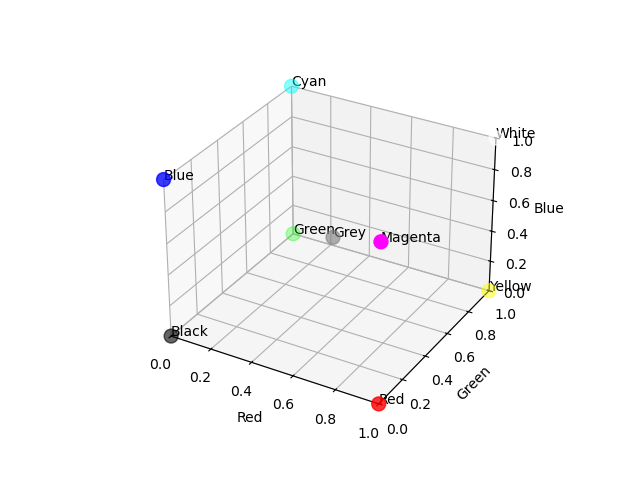

In [17]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Define the colors for additive mixing (RGB)
additive_colors = {
    'Red': (1, 0, 0),
    'Green': (0, 1, 0),
    'Blue': (0, 0, 1),
    'Yellow': (1, 1, 0),
    'Cyan': (0, 1, 1),
    'Magenta': (1, 0, 1),
    'White': (1, 1, 1),
    'Black': (0, 0, 0),
    'Grey': (0.5, 0.5, 0.5)
}

# Create arrays for plotting
colors = list(additive_colors.values())
labels = list(additive_colors.keys())
x = np.array([r for r, g, b in colors])
y = np.array([g for r, g, b in colors])
z = np.array([b for r, g, b in colors])

# Plot points in the 3D space
ax.scatter(x, y, z, c=colors, s=100)

# Set labels
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

# Set limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)

# Annotate points
for i in range(len(labels)):
    ax.text(x[i], y[i], z[i], labels[i], size=10, zorder=1)

plt.show()

## Assignment 2: Twodimensional Convolution (8 points)

This exercise is purely theoretical and does not require implementation.

### a) Definition

Describe in your own words how convolution works. Also provide the formula from the lecture and explain its idea.

- Convolution is a mathematical operation used in image processing to apply a filter (or kernel) to an image. The process involves sliding the filter over the image and calculating the weighted sum of the pixels beneath the filter for each position. This enables various image transformations, such as blurring, sharpening, and edge detection, by manipulating pixel intensity based on their spatial relationships.

The convolution operation is mathematically described by the equation:

$
g'(x, y) = (g * k)(x, y) = \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i + m, j + n) \cdot g(x + i, y + j)
$

- **Components**:
  - $g(x, y)$: The input image.
  - $k(i, j)$: The filter kernel (or mask) with size $(2m + 1) \times (2n + 1)$.
  - $g'(x, y)$: The resulting image after applying the convolution.
  

### Idea Behind the Formula
1. **Sliding the Kernel**: The filter k is moved across the image g, pixel by pixel.
2. **Weighting Pixels**: For each position, the kernel defines how much influence each pixel has based on its distance from the center of the kernel.
3. **Calculating the Result**: The sums compute a new pixel value g'(x, y) by multiplying corresponding pixel values from the image and the filter, accumulating these products to yield a single resulting pixel in the transformed image.

Convolution can be viewed as a series of local operations to determine how each pixel in the image interacts with its neighbors under the influence of the chosen filter, which can be tailored for specific effects in image enhancement processes.

### b) Properties
Is convolution linear or non-linear? Is it homogenous or inhomogenous? Use formulae and proof your answers. 

Hint:

From  CV-03 slide 49: A function $f$ is linear iff 
$f \left( a \cdot x \right) = a \cdot f \left( x \right) $
and
$f \left( x_1 + x_2 \right) = f \left( x_1 \right) + f \left( x_2 \right)$

A function is homogeneous if translating the filtered image is the same as filtering the translated image. I.e. $\operatorname{translate}(g\ast k,\Delta x,\Delta y)[x,y] = (\operatorname{translate}(g,\Delta x,\Delta y)\ast k)[x,y]$


### Convolution Properties

#### Proof of Linearity of Convolution

To prove that convolution is linear, we need to show that it satisfies both homogeneity and additivity.

#### 1. Homogeneity

For any scalar \(c\) and function \(g(x, y)\):

$ (c \cdot g * k)(x, y) = \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot (c \cdot g(x + i, y + j)) $

This simplifies to:

$ = c \cdot \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot g(x + i, y + j) = c \cdot (g * k)(x, y) $

#### 2. Additivity

For two functions $g_1(x, y)$ and $g_2(x, y)$:

$ ((g_1 + g_2) * k)(x, y) = \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot (g_1(x + i, y + j) + g_2(x + i, y + j)) $

This separates into:

$ = \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot g_1(x + i, y + j) + \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot g_2(x + i, y + j) $

Thus, 

$ = (g_1 * k)(x, y) + (g_2 * k)(x, y) $

### Conclusion

Since both **homogeneity** and **additivity** properties are satisfied:

- Convolution is **linear**.

### Proof of Homogeneity of Convolution

To show that convolution is homogeneous, we need to verify that translating the filtered image is the same as filtering the translated image:

$ \text{translate}(g * k, \Delta x, \Delta y)[x, y] = \text{translate}(g, \Delta x, \Delta y) * k[x, y]$

#### Left Side: Translated Convolution

Translating the convolved image:

$
\text{translate}(g * k, \Delta x, \Delta y)[x, y] = (g * k)[x - \Delta x, y - \Delta y]
$

By the convolution definition:

$
(g * k)(x - \Delta x, y - \Delta y) = \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot g((x - \Delta x) + i, (y - \Delta y) + j)
$

#### Right Side: Convolution of Translated Image

Translating the input image first and then convolving:

$
\text{translate}(g, \Delta x, \Delta y) * k[x, y] = g(x - \Delta x, y - \Delta y) * k
$

Applying convolution:

$
= \sum_{i=-m}^{m} \sum_{j=-n}^{n} k(i,j) \cdot g((x - \Delta x) + i, (y - \Delta y) + j)
$

#### Conclusion

Since both sides:

$
\text{translate}(g * k, \Delta x, \Delta y)[x, y] = \text{translate}(g, \Delta x, \Delta y) * k[x, y]
$

yield the same result, we conclude that convolution is **homogeneous**.

### c) Complexity

Assume an image $g$ of size $M\times N$ and a kernel $k$ of size $(2m+1)\times(2n+1)$. How many operations (additions and multiplications) are required to compute a convoluted image $g\ast k$ (of the same size as $g$)?

To compute the convolution of an image g of size $ M \times N $ with a kernel k of size $(2m + 1) \times (2n + 1)$:

1. **Total Multiplications**: 
   $
   M \times N \times (2m + 1)(2n + 1)
   $

2. **Total Additions**: 
   $
   M \times N \times ((2m + 1)(2n + 1) - 1)
   $

### Total Operations

Combining both, the total number of operations (multiplications + additions) is:

$
\text{Total operations} = M \times N \times (2(2m + 1)(2n + 1) - 1)
$ 

This gives the overall computational cost of the convolution process.

### d) Separability

What is a separable kernel? Describe, how it can be applied more efficiently. Compute the number of operations for getting $g\ast k$ (as in (c), but with a separable kernel $k$) and compare the results. Assume that the kernel is of size $m \times n$ and the image is of size $M \times N$. Compute the number of operations first for a single pixel and then extend your answer to the whole image. Ignore the normalization of the kernel, i.e. the fraction in front.

Note that here we define the kernel size as $m \times n$ as opposed to Assignment *c)*. This is a shorter notation.

### Separable Kernel

A **separable kernel** is a type of convolution kernel that can be expressed as the outer product of two one-dimensional vectors. For example, a kernel \( k \) of size \( m \times n \) can be written as:

$ 
k(i, j) = u(i) \cdot v(j) 
$

where \( u \) is a vector of size \( m \) and \( v \) is a vector of size \( n \). This property allows us to break down a two-dimensional convolution into two one-dimensional convolutions.

### Efficient Application of Separable Kernels

When applying a separable kernel, the convolution process can be performed in two steps:

1. **Horizontal Convolution**: First, convolve the image with the horizontal vector \( u \).
2. **Vertical Convolution**: Next, convolve the result of the first step with the vertical vector \( v \).

This separation reduces the number of operations significantly compared to a full two-dimensional convolution.

### Number of Operations for a Single Pixel

For a kernel of size $ m \times n $:

- **Horizontal Convolution**:
  - **Total Multiplications**:  m 
  - **Total Additions**:  m - 1 
  
- **Vertical Convolution**:
  - **Total Multiplications**:  n 
  - **Total Additions**:  n - 1 

#### Total Operations for One Pixel

Combining both operations for a single pixel:

$ 
\text{Total operations for one pixel} = m + (m - 1) + n + (n - 1) = 2m + 2n - 2 
$

### Total Operations for the Whole Image

Assuming the image g is of size $ M \times N $:

- **Total pixels in the image**: $ M \times N $

Thus, the total number of operations for the entire image is:

$ 
\text{Total operations} = (2m + 2n - 2) \times (M \times N) = (2M \times N)(m + n - 1) 
$

### Comparison with Non-Separable Kernel

For a non-separable kernel of size $ m \times n  $:

- **Total Multiplications**: 
$ 
M \times N \times m \times n
$

- **Total Additions**:
$ 
M \times N \times ((m \times n) - 1) 
$

### Summary of Operations

- **Total operations for non-separable kernel**:
$ 
\text{Total operations} = M \times N \times (2(m \times n) - 1) 
$

- **Total operations for separable kernel**:
$ 
\text{Total operations} = (2M \times N)(m + n - 1) 
$

### Conclusion

Using a separable kernel significantly reduces the number of operations needed for the convolution process, making it more efficient than using a non-separable kernel.

## Assignment 3: Applying Convolution (4 points)

In this exercise you will apply convolution with different kernels. You may use the function `scipy.ndimage.convolve` to solve this task. Check the documentation to learn how to use this function. In this assignment you do not have to implement the convolution yourself. Realize the following filters, describe their effect and possible applications.

### a) Box filter

Box Filter
A box filter (or average filter) is used to smooth an image by averaging the pixel values within a defined rectangular kernel.

**Effect:** It reduces noise and blurs the image, leading to a loss of fine details while preserving the overall structure.
Applications: Commonly used in image preprocessing, such as reducing noise before further processing, creating a low-pass filter in computer vision, and for texture analysis.

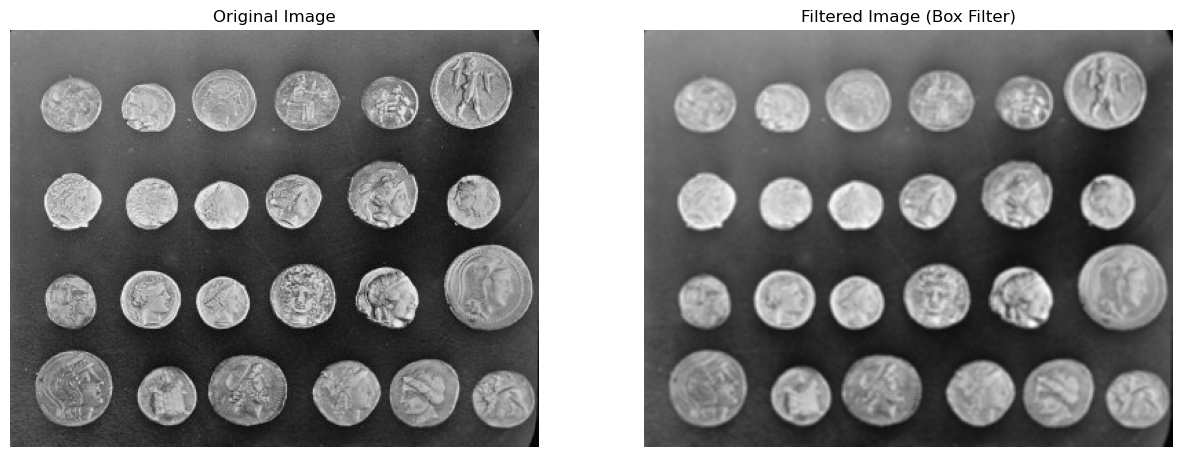

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from imageio.v2 import imread
from skimage import data
from scipy.ndimage import convolve

# Load an image
image = data.coins().astype(np.float32)

# Define the box filter (3x3 kernel)
kernel_size = 3
box_filter = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)+200

# Apply the box filter
filtered_image = convolve(image, box_filter)

# Display the original and filtered images
fig = plt.figure(figsize=(15, 7))
a = fig.add_subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
a = fig.add_subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title('Filtered Image (Box Filter)')
plt.axis('off')
plt.show()

### b) Gaussian filter

You may try different filter sizes.

Gaussian Filter
Effect: The Gaussian filter blurs the image based on a Gaussian function, which gives more weight to pixels nearer to the center of the kernel. This results in a smoother image while minimizing artifacts.
Applications: Commonly used in image processing for noise reduction, image smoothing, and as a preprocessing step before edge detection algorithms.

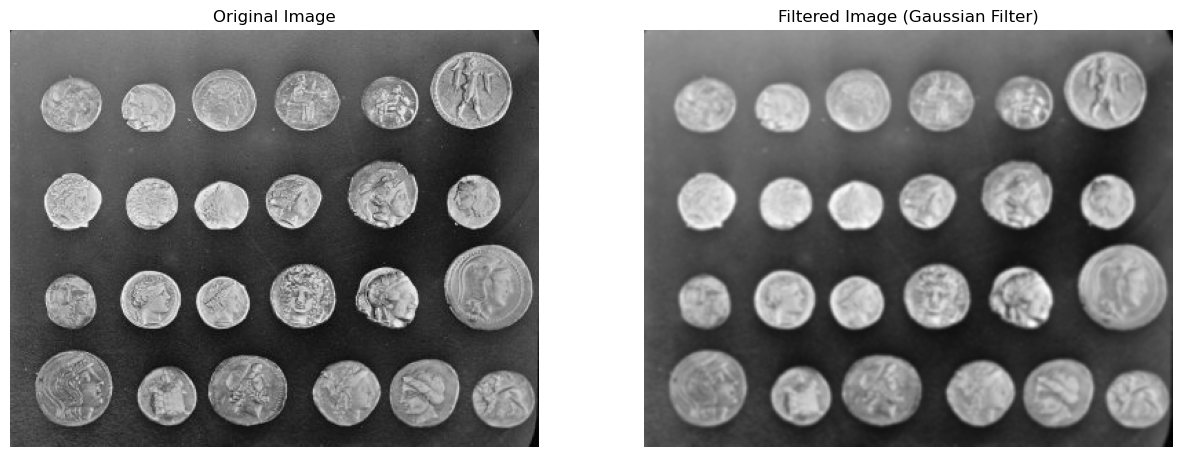

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from imageio.v2 import imread
from skimage import data
from scipy.ndimage import convolve
from scipy.ndimage import gaussian_filter

# Load an image
image = data.coins().astype(np.float32)

# Apply the Gaussian filter
sigma = 1  # Standard deviation for Gaussian kernel
filtered_image = gaussian_filter(image, sigma=sigma)

# Display the original and filtered images
fig = plt.figure(figsize=(15, 7))
a = fig.add_subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
a = fig.add_subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title('Filtered Image (Gaussian Filter)')
plt.axis('off')
plt.show()

### c) Sobel filter

Try horizontal, vertical, and diagonal sobel filters.

**Effect:** The Sobel filter is used for edge detection. It calculates the gradient of the image intensity, highlighting regions of high spatial frequency that correspond to edges.
Applications: Commonly used in feature detection, image segmentation, and object recognition.

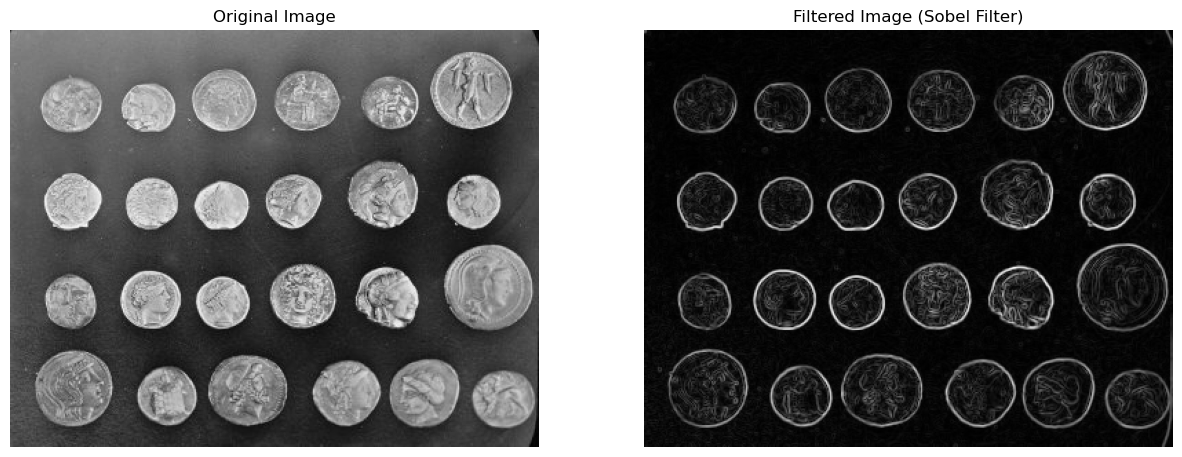

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from imageio.v2 import imread
from skimage import data
from scipy.ndimage import convolve

# Load an image
image = data.coins().astype(np.float32)

# Define Sobel kernels for horizontal and vertical edge detection
sobel_horizontal = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

sobel_vertical = np.array([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]])

# Apply the Sobel filter
filtered_image_h = convolve(image, sobel_horizontal)
filtered_image_v = convolve(image, sobel_vertical)

# Combine the two responses
filtered_image = np.sqrt(filtered_image_h**2 + filtered_image_v**2)

# Normalize the resulting image for better visualization
filtered_image = (filtered_image / np.max(filtered_image)) * 255

# Display the original and filtered images
fig = plt.figure(figsize=(15, 7))
a = fig.add_subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
a = fig.add_subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title('Filtered Image (Sobel Filter)')
plt.axis('off')
plt.show()

### d) Unsharp Mask

One method to sharpen images is Unsharp Mask in which a negative unsharp mask is added to the original image as follows:

$$\text{Sharpened Image} = \text{Original Image} + (\text{Original Image} - \text{Unsharp Image}) \cdot \text{Amount}$$

The unsharp image can be computed by convolution with a Gaussian Kernel. Implement unsharp masking with a $5\times5$ Gaussian Kernel and a sharpening amount of $1.5$. Use the allready defined gaussian kernel "gauss_5".

Hint: To get good results the final images needs to be clipped to values between $0$ and $255$, i.e. all negative values are set to zero and all values bigger than $255$ are set to $255$.

You may experiment with large or negative sharpening amounts.

* Why is Unsharp Masking sharpening an image?
* What is the difference between normalizing and clipping an image?


- Why is Unsharp Masking sharpening an image?

Unsharp Masking enhances edges by increasing the contrast between adjacent pixels. It emphasizes areas of rapid intensity change (edges), which gives the perception of sharpness.


- What is the difference between normalizing and clipping an image?

Normalizing adjusts the pixel values to a specific range (e.g., 0 to 1 or 0 to 255) while preserving the data's distribution. Clipping, on the other hand, cuts off values that exceed or fall below specified limits without altering the distribution of remaining values. This can prevent artifacts produced by out-of-range values.




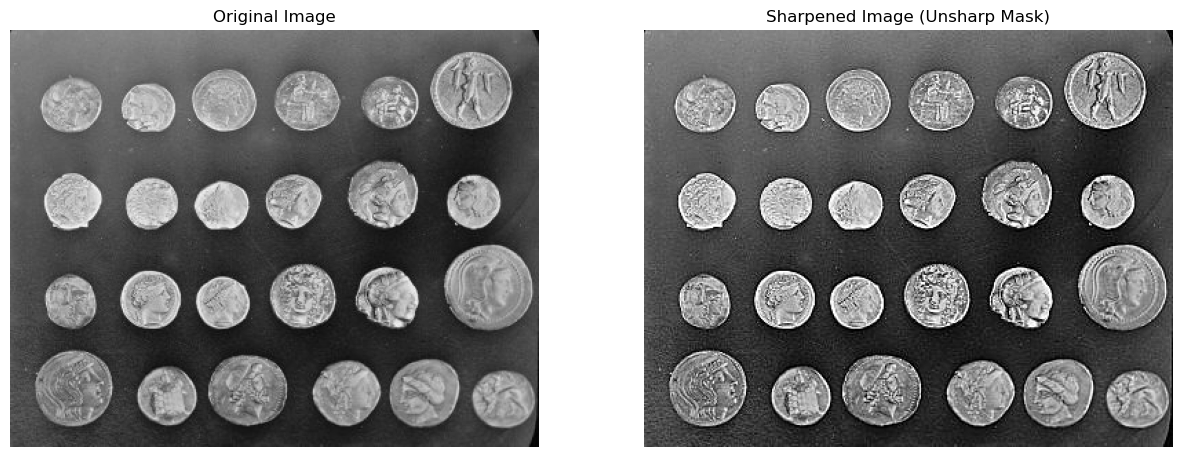

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from imageio.v2 import imread
from skimage import data
from scipy.ndimage import convolve

# Load an image
image = data.coins().astype(np.float32)

# Define sharpening amount
amount = 1.5

# Define the Gaussian kernel
gauss_5 = 1/256 * np.asarray([[1, 4, 6, 4, 1],
                               [4, 16, 24, 16, 4],
                               [6, 24, 36, 24, 6],
                               [4, 16, 24, 16, 4],
                               [1, 4, 6, 4, 1]])

# Step 1: Compute the unsharp image
unsharp_image = convolve(image, gauss_5)

# Step 2: Compute the sharpened image
sharpened_image = image + (image - unsharp_image) * amount

# Step 3: Clip the values to be between 0 and 255
sharpened_image = np.clip(sharpened_image, 0, 255)

# Convert back to uint8 for proper display
sharpened_image = sharpened_image.astype(np.uint8)

# Display the original and unsharp masked images
fig = plt.figure(figsize=(15, 7))
a = fig.add_subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
a = fig.add_subplot(1, 2, 2)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image (Unsharp Mask)')
plt.axis('off')
plt.show()

## Assignment 4: Implementing Convolution (4 points)

Now implement your own 2-dimensional convolution function. The function should take an image and a kernel as arguments and return an image of the same size, containing the result of convolving the image with the kernel.

**(a)** First: you may notice a problem at the boundaries of the image. Describe the problem and possible solutions. Implement at least one of them in (b).

When performing 2D convolution on an image, a common issue arises at the borders of the image due to the kernel extending beyond the image dimensions. This can lead to missing data for those edge pixels, resulting in undefined behavior or artifacts.

**Possible Solutions:**

- Zero Padding: Extend the edges of the image by adding a border of zeros around it. This allows the kernel to be applied at the borders without going out of bounds.

- Reflect Padding: Reflect the pixels at the edges. This method uses the nearest pixel values and can help in preserving the edges more naturally.

- Replicate Padding: Extend the edge pixels outward. The border pixel values are repeated to fill in the padding.

- Valid Convolution: Only compute output for positions where the kernel fully overlaps the image, effectively reducing the output size.

**(b)** Now implement your function. Apply it with different kernels and compare the results with the output of the library function `scipy.ndimage.correlate` (bonus question: why not `scipy.ndimage.convolve`?).

The scipy.ndimage.convolve function applies a mathematical convolution, which includes flipping the kernel before the convolution operation, as per the definition of convolution. In contrast, scipy.ndimage.correlate does not flip the kernel, thus directly applying it as is.

This implementation and the comparison with the library function will highlight the effectiveness of the manual convolution function as well!

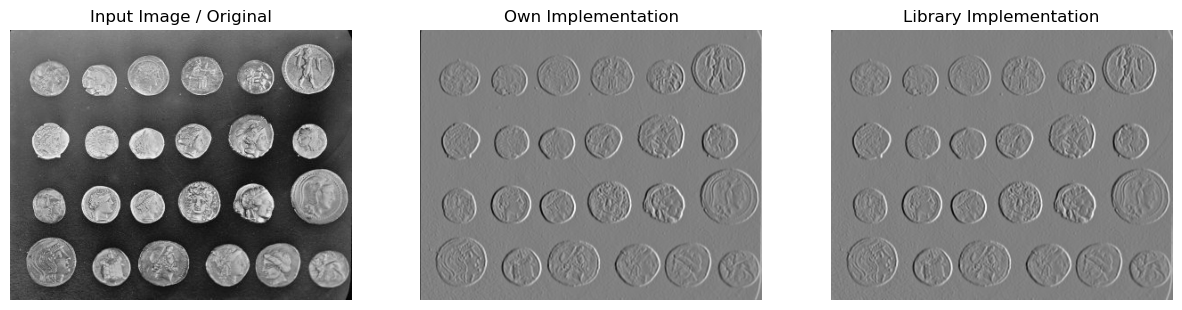

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import imageio.v3 as iio
import scipy.ndimage

def my_convolve2d(img, kern):
    """Convolve an image with a kernel.

    Args:
        img (np.ndarray): The image, provided as a two-dimensional array.
        kern (np.ndarray): The kernel, also a two-dimensional array.
        
    Returns:
        result (np.ndarray): The convolved image. 
    """
    
    # Store the image size for easier access
    M, N = img.shape
    # Store the kernel size
    m, n = kern.shape
    # Half kernel sizes
    mh, nh = (m // 2, n // 2)
    
    # Initialize the result matrix
    result = np.zeros((M, N))
    
    # Pad the image with zeros
    padded_img = np.pad(img, ((mh, mh), (nh, nh)), mode='constant', constant_values=0)
    
    # Compute the convolution
    for i in range(M):
        for j in range(N):
            # Extract the region of interest
            region = padded_img[i:i + m, j:j + n]
            # Perform convolution (element-wise multiplication and sum)
            result[i, j] = np.sum(region * kern)
    
    return result

# Apply your function to an image:
image = iio.imread("imageio:coins.png").astype(np.float32)

# Try different filters (kernels)
kernel = 1/4 * np.asarray([[1, 0, -1], [2, 0, -2], [1, 0, -1]])

fig = plt.figure(figsize=(15, 7))
fig.add_subplot(1, 3, 1)
plt.title("Input Image / Original")
plt.imshow(image, cmap='gray')
plt.axis('off')
fig.add_subplot(1, 3, 2)
plt.title("Own Implementation")
plt.imshow(my_convolve2d(image, kernel), cmap='gray')
plt.axis('off')
fig.add_subplot(1, 3, 3)
plt.title("Library Implementation")
plt.imshow(scipy.ndimage.correlate(image, kernel), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import imageio.v3 as iio
import scipy.ndimage

def my_convolve2d(img, kern):
    """Convolve an image with a kernel.

    Args:
        img (np.ndarray): The image, provided as a two-dimensional array.
        kern (np.ndarray): The kernel, also a two-dimensional array.
        
    Returns:
        result (np.ndarray): The convolved image. 
        
    """
    
    # store the image size for easier access
    M,N = img.shape
    # store the kernel size
    m,n = kern.shape
    # and also the half kernel size
    mh, nh = (m//2, n//2)
    
    # Initialize the result matrix
    result = np.zeros((M,N))
    
    # Compute the convolution
    # YOUR CODE HERE
    raise NotImplementedError()

    return result

# Apply your function to an image:
image = iio.imread("imageio:coins.png").astype(np.float32)

# Try different filters (kernels)
kernel = 1/4 * np.asarray([[1,0,-1],[2,0,-2],[1,0,-1]])

fig = plt.figure(figsize=(15,7))
fig.add_subplot(1,3,1)
plt.title("input image / original")
plt.imshow(image, cmap = 'gray')
plt.axis('off')
fig.add_subplot(1,3,2)
plt.title("own implementation")
plt.imshow(my_convolve2d(image, kernel), cmap = 'gray')
plt.axis('off')
fig.add_subplot(1,3,3)
plt.title("library implementation")
plt.imshow(scipy.ndimage.correlate(image, kernel), cmap = 'gray')
plt.axis('off')
plt.show()